# Exploratory Data Analysis — Loan Default Prediction
**Projet MLOps | Banque de détail**  
Objectif : analyser le jeu de données de prêts afin de comprendre les variables qui prédisent le défaut de paiement.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

In [2]:
DATA_PATH = '../Data/Loan_Data.csv'

## Informations générales

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 8)


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [5]:
df.describe().round(2)

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,4974577.00,1.46,4159.68,8718.92,70039.90,4.55,637.56,0.19
std,2293889.71,1.74,1421.40,6627.16,20072.21,1.57,60.66,0.39
min,1000324.00,0.00,46.78,31.65,1000.00,0.00,408.00,0.00
25%,2977661.00,0.00,3154.24,4199.84,56539.87,3.00,597.00,0.00
50%,4989501.50,1.00,4052.38,6732.41,70085.83,5.00,638.00,0.00
75%,6967210.25,2.00,5052.90,11272.26,83429.17,6.00,679.00,0.00
max,8999789.00,5.00,10750.68,43688.78,148412.18,10.00,850.00,1.00


## Analyse de la qualité des données

In [6]:
# Valeurs manquantes
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

In [7]:
# Doublons
df.duplicated().sum()

np.int64(0)

In [8]:
# Valeurs aberrantes (outliers)
df.describe(percentiles=[.01, .05, .25, .75, .95, .99])

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
1%,1.079081e+06,0.000000,1230.977265,583.845780,22676.764735,1.000000,490.990000,0.000000
5%,1.415055e+06,0.000000,2044.005453,1236.690508,37001.349620,2.000000,536.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
95%,8.583714e+06,5.000000,6646.026569,22900.195794,102825.766100,7.000000,735.000000,1.000000


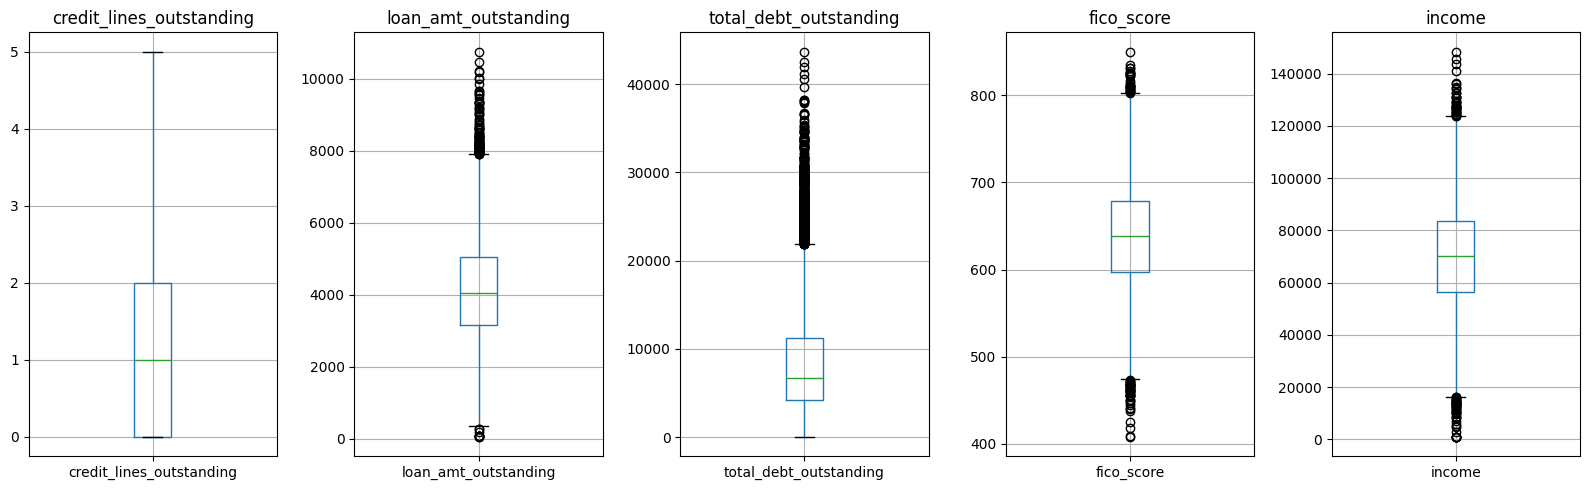

In [25]:
import matplotlib.pyplot as plt

cols_numeriques = ["credit_lines_outstanding", "loan_amt_outstanding",
                   "total_debt_outstanding", "fico_score", "income"]

fig, axes = plt.subplots(1, len(cols_numeriques), figsize=(16, 5))

for i, col in enumerate(cols_numeriques):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Les variables *loan_amt_outstanding* et *total_debt_outstanding* affichent un nombre important de valeurs extrêmes vers le hau. Ces emprunteurs cumulent des montants de prêt et des dettes élevées, ce qui constitue un signal de risque important, particulièrement lorsque ces profils se combinent à un FICO score faible.

La variable *fico_score* présente des outliers dans les deux sens, avec des scores anormalement bas (sous 450) qui pourraient indiquer des erreurs de saisie ou des profils à très haut risque de défaut, susceptibles d'influencer fortement un futur modèle prédictif. Nous vérifierons cela avec les distributions, ci-dessous.

## Analyse des variables numériques

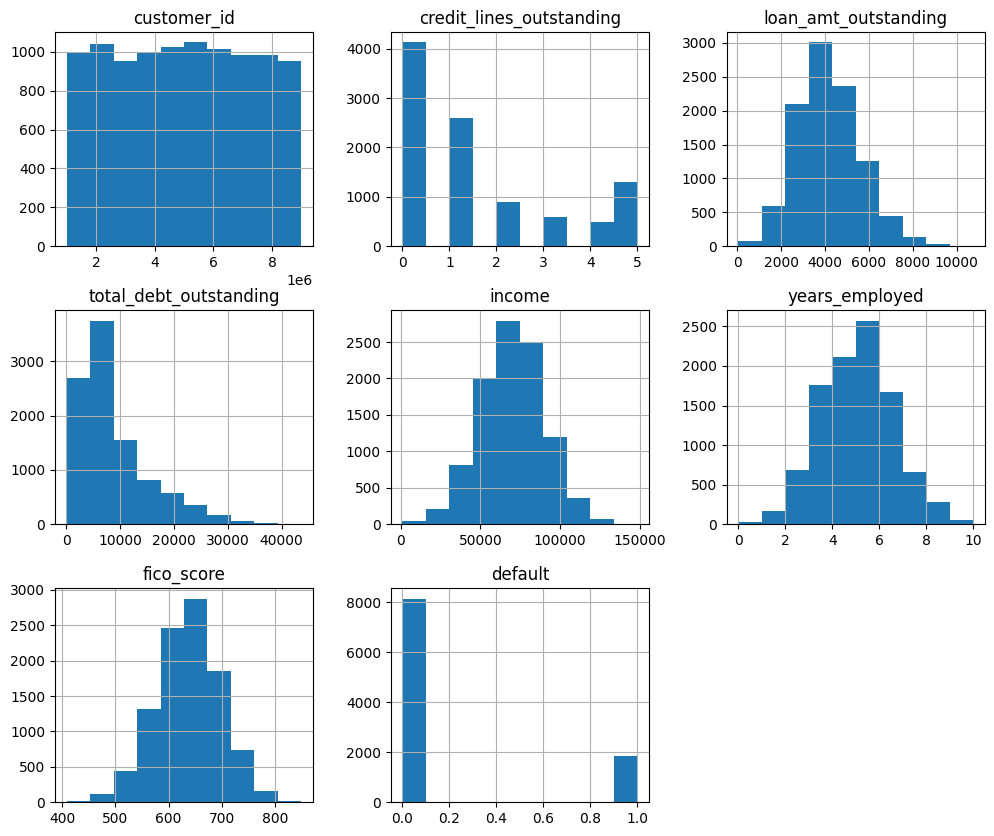

In [14]:
# Distibution des variables
df.hist(figsize=(12,10))
plt.show()

La variable *fico_score* qui nous inquiétait particulièrement a une distribution en forme de cloche, légèrement asymétrique à gauche. Les valeurs aberrantes sous 500 ne sont pas isolées, elles font partie d'une montée progressive vers le pic.

## Corrélations

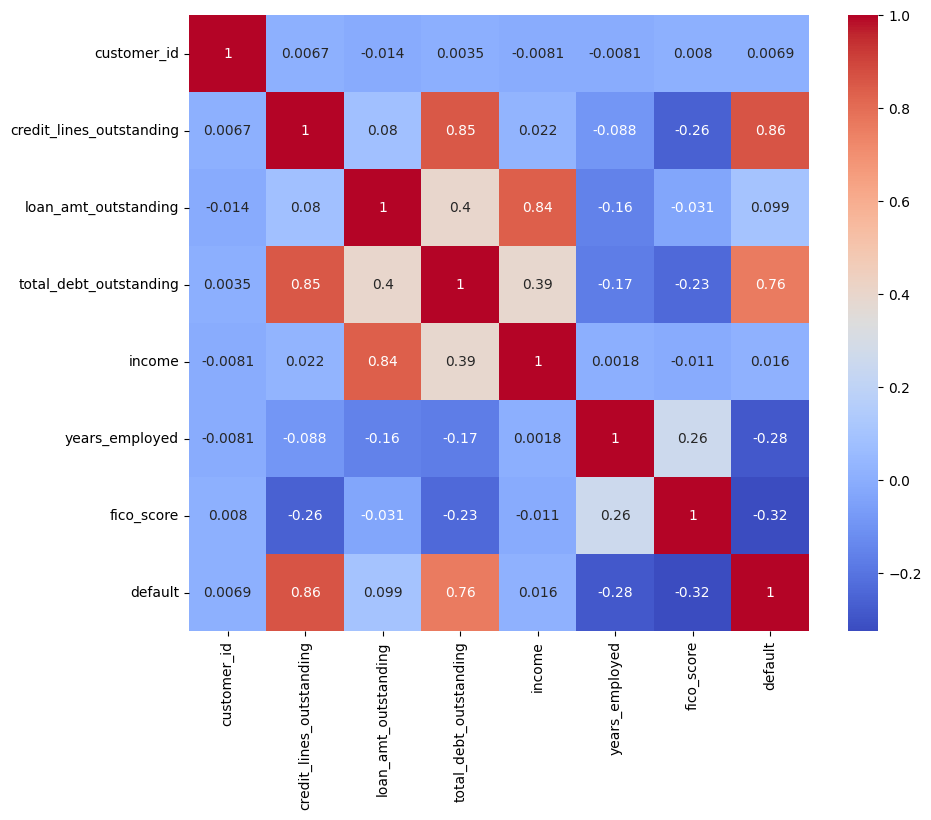

In [13]:
plt.figure(figsize=(10$ ,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

- La variable *default* est associée aux variables *credit_lines_outstanding* et *total_debt_outstanding* (corrélations respectives de 0.86 et 0.76). Ainsi, un nombre élevé de lignes de crédit et un montant de dette important sont liés à un risque plus élevé de défaut de paiement, et inversement, peu de lignes de crédit et une dette faible sont associés à une meilleure santé financière du client."

- Les variables *income* et *loan_amt_outstanding* sont corrélées de 0.85, ce qui suggère qu'elles évoluent conjointement, sans qu'on puisse en déduire un lien de causalité.

## Analyse de la variable cible : default

In [21]:
#Somme des valeurs de la variable cible avec leur pourcentage
pd.DataFrame({
    "count": df["default"].value_counts(),
    "pourcentage": df["default"].value_counts(normalize=True) * 100
})

,count,pourcentage
default,,
0,8149,81.49
1,1851,18.51


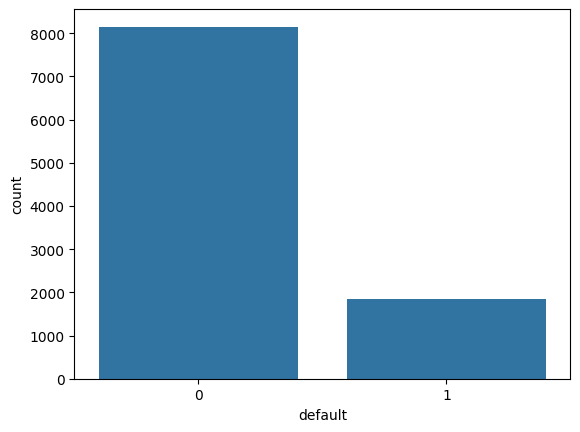

In [16]:
sns.countplot(x='default', data=df)
plt.show()

1 851 parmi 10 000 clients de la banque sont en default de paiement de leurs prêts, ce qui équivaut à 18,51% du total des clients

## Rapport entre la variable cible et les variables prédicitves

a) Boxplots groupés en fonction de la variable cible

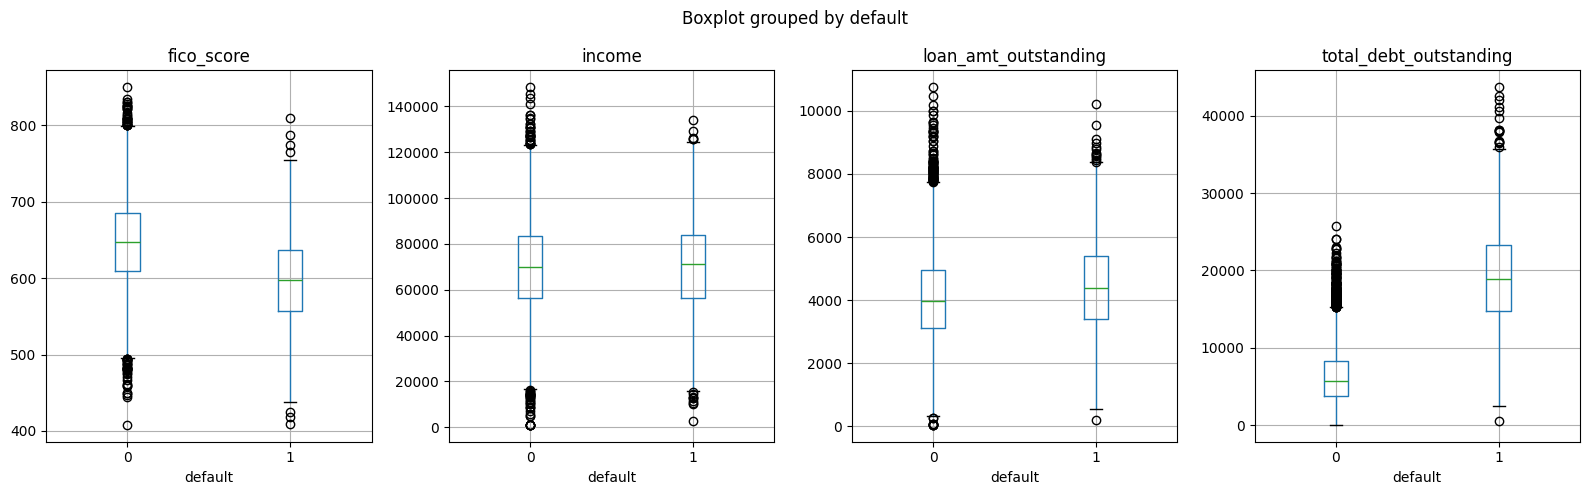

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(["fico_score", "income", "loan_amt_outstanding", "total_debt_outstanding"]):
    df.boxplot(column=col, by="default", ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

- La variable *fico_score* constitue une variable prédictive intéressante : la boîte du groupe 0 (pas de défaut) est clairement plus haute que celle du groupe 1 (défaut). En d'autres mots, cette variable distingue bien les deux groupes : les clients qui ne font pas défaut ont des scores FICO meilleurs.

- La variable *total_debt_outstanding* permet également de distinguer les deux types de clients. La boîte du groupe 1 (défaut) est nettement plus haute, reflétant une dette totale bien plus élevée que celle des clients sans défaut.

- Présentant des distributions similaires, les variables *income* et *loan_amt_outstanding* se révèlent moins pertinentes à la prédiction.

b) Taux de defaut selon la nombre de crédits

In [30]:
# Voir le nombre de clients dans chaque groupe
df.groupby("credit_lines_outstanding")["default"].agg(["mean", "count"]) * 100

,mean,count
credit_lines_outstanding,,
0,0.000000,412800
1,0.000000,259000
2,0.776053,90200
3,22.871452,59900
4,85.123967,48400
5,99.845798,129700


La segmentation par nombre de crédits révèle une tendance non linéaire très marquée : les clients avec 0 ou 1 crédit ne font jamais défaut, tandis que le taux explose à partir de 3 lignes de crédit pour atteindre près de 99.8% à 5 lignes. Cette relation quasi-mécanique suggère que cette variable pourrait être construite à partir du défaut lui-même dans ce dataset, ce qui nécessiterait une vérification avant de l'utiliser dans un modèle prédictif.

c) Distribution du revenu selon le défaut

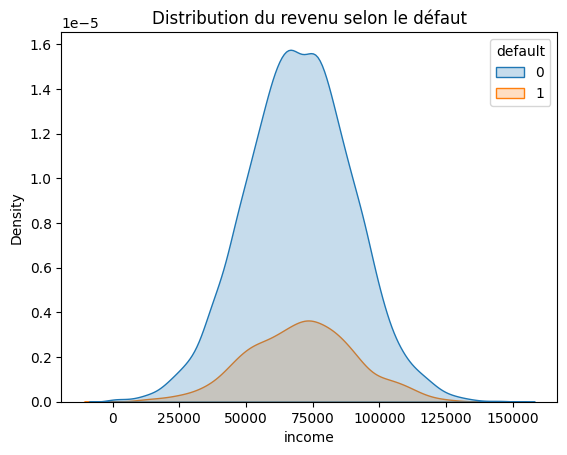

In [20]:
sns.kdeplot(data=df, x="income", hue="default", fill=True)
plt.title("Distribution du revenu selon le défaut")
plt.show()

Cette visualisation permet de comparer la distribution des revenus entre les clients en défaut et ceux qui ne le sont pas. Alors que l'idée reçue nous dit que les clients avec un revenu plus faible semblent présenter un risque plus élevé, les deux courbes de notre distribution ont la même forme et le même centre (autour de 70 000).

Le revenu semblerait ne pas être un facteur discriminant du défaut de paiement dans ce dataset : la courbe orange (défaut=1) étant simplement plus basse en raison du faible nombre de clients en défaut (18,5% du total). Cependant, nous sommes conscients des limites de l'analyse univariée. Combinée à d'autres variables, income pourrait acquérir une importance plus significative, ce qui justifie le feature engineering prévu avant la construction de nos modèles